# interrupt와 Command로 구현하는 Human-in-the-loop

Human-In-The-Loop(HITL)은 Agent가 모든 판단을 자동으로 끝내지 않고, **사람의 확인이 필요한 지점에서 실행을 잠시 멈추는 설계**이다. 가격·재고처럼 모델이 확정할 수 없는 정보나 승인·결제처럼 위험한 작업에 사용한다.

이 실습에서는 `interrupt()`가 질문을 외부로 내보내고, 사람이 준 값을 `Command(resume=...)`으로 다시 넣는다. Checkpointer는 그 사이의 State와 실행 위치를 저장한다.

## 전체 흐름
![질문부터 interrupt 중단, 사람 입력과 재개를 거쳐 END에 도달하는 흐름](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/05_hitl_interrupt_resume_flow.svg)


1. 질문을 받은 `chatbot`이 `AIMessage.tool_calls`로 `human_assist` 호출을 요청한다.
2. `ToolNode`가 Tool을 실행하면 `interrupt({"query": query})`에서 멈춘다.
3. Checkpointer가 State를 저장하고, 호출자는 `__interrupt__`에서 요청 내용을 읽는다.
4. 사람의 답변을 같은 `thread_id`의 `Command(resume=...)`으로 전달한다.
5. 그 값이 `interrupt()`의 반환값이 되어 Tool 결과인 `ToolMessage`로 이어진다.
6. `chatbot`이 Tool 결과를 다시 읽고 최종 답변을 만들면 `END`에 도달한다.

> 이 흐름도는 [LangGraph 공식 Interrupts 문서](https://docs.langchain.com/oss/python/langgraph/interrupts)와 [Checkpointers 문서](https://docs.langchain.com/oss/python/langgraph/checkpointers)를 바탕으로 현재 실습 코드에 맞게 재구성한 이미지이다.


## 패키지 설치

LangGraph 실행기와 OpenAI·Tavily 연동 패키지를 준비한다. 패키지는 **중단 기능**만 제공하며, `interrupt payload`를 화면에 보여 주고 사람 답변을 받는 UI는 애플리케이션에서 따로 구현한다.


In [1]:
# %pip install -U langgraph langchain-openai langchain-tavily python-dotenv


## 모델과 검색 인증 준비

OpenAI는 `chatbot`의 판단과 답변에, Tavily는 검색 Tool에 사용한다. 필수 키는 **존재 여부만 검사**하고 값은 출력하지 않는다.

LangSmith는 실행 추적용 선택 기능이다. 추적 키가 없어도 HITL 그래프 자체는 실행할 수 있다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(
    usecwd=True,
)
load_dotenv(
    dotenv_path,
    override=False,
)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-hitl")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 검색 Tool의 독립 실행

최신 웹 정보는 사람에게 묻기보다 Tavily 검색으로 처리할 수 있다. 그래프에 넣기 전에 Tool을 직접 호출하여 **질의 dict → 검색 → 결과 목록**의 기본 경로를 확인한다.


In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

tavily_tool.invoke({
    'query': 'LangGraph의 Human-in-the-loop란 무엇인가?',
})


{'query': 'LangGraph의 Human-in-the-loop란 무엇인가?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://docs.langchain.com/oss/python/langchain/human-in-the-loop',
   'title': 'Human-in-the-loop - Docs by LangChain',
   'content': "The Human-in-the-Loop (HITL) middleware lets you add human oversight to agent tool calls. When a model proposes an action that might require review—for example, writing to a file or executing SQL—the middleware can pause execution and wait for a decision. It does this by checking each tool call against a configurable policy. If intervention is needed, the middleware issues an interrupt that halts execution. The graph state is saved using LangGraph’s persistence layer, so execution can pause [...] from langgraph.types import Command from  langgraph. types import  Command # Human-in-the-loop leverages LangGraph's persistence layer.# Human-in-the-loop leverages LangGraph's persistence layer.# You must provide a thread ID to 

## interrupt를 호출하는 사람 요청 Tool

`human_assist`는 모델이 확정할 수 없는 질문을 사람에게 전달하는 Tool이다. 여기서는 **나가는 값**과 **들어오는 값**을 구분해야 한다.

- `interrupt({"query": query})`: 호출자에게 내보내는 **중단 요청 payload**이다.
- `Command(resume={"data": ...})`: 사람이 그래프에 다시 넣는 **재개 값**이다.
- `human_response["data"]`: 재개 값에서 꺼낸 문자열이며 Tool 실행 결과가 된다.

즉 `interrupt()` 호출은 한 줄이지만, 처음에는 실행을 멈추고 재개 후에는 `resume` 값을 반환하는 두 역할을 한다.

### 동적 interrupt와 정적 breakpoint의 차이

현재 실습의 `interrupt()`는 `human_assist`가 실제 실행될 때만 멈추는 **동적 interrupt**이다. 반면 `compile(interrupt_before=["tools"])`처럼 Node 이름을 지정하는 방식은 해당 Node 실행 전마다 멈추는 **정적 breakpoint**이다. 이번에는 사람에게 질문을 보내고 그 답을 Tool 결과로 받아야 하므로 동적 interrupt를 사용한다.


In [14]:
from langchain_core.tools import tool
from langgraph.types import interrupt

@tool # python 함수를 LLM과 Tool Node가 호출할수 있는 Tool 객체로 변환
def human_assist(query:str) -> str:
    '''
    자동으로 확정할 수 없는 문의를 사람에게 전달하고 답변을 반환한다
    '''
    # interrupt(payload):
    # - payload를 호출자에게 노출하고 현재 graph실행을 중단.
    # - payload : 전달되는 실제 데이터의 본문
    #   + payload는 외부 UI/API가 인식할수 있도록 JSON 직렬화가 가능한 값이어야 한다.
    human_response = interrupt({
        'query': query,# 사람에게 확인 받을 질문
    })
    # ---------여기서 멈춤------------

    # 사람이 질문에 답변하면 여기서부터 시작
    # 흐름이 재개될때 Command(resume={'data':'답변'})의 resume dict가 반환값이 된다
    return human_response['data'] # == 사람의 답변

## 두 Tool을 Chat Model에 바인딩하기

`tools`는 실제로 실행할 수 있는 **Tool 객체 목록**이다. 반면 `AIMessage.tool_calls`는 모델이 “이 Tool을 이 인자로 호출해 달라”고 만든 **호출 요청 목록**이다.

`bind_tools()`는 Tool의 이름과 입력 스키마를 모델에 알려 줄 뿐 실행하지 않는다. 실제 호출은 뒤의 `ToolNode(tools)`가 담당한다.


In [16]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model_name=OPENAI_CHAT_MODEL,
    use_responses_api=True,
)

# 도구 목록
tools= [tavily_tool, human_assist]
# llm이 사용자 질문을 분석하여, 필요 시 tools 목록에 존재하는 도구(tool)을 알아서 호출 -> tool_calls 형태
llm_with_tools = llm.bind_tools(tools)


## 중단과 재개를 완성할 다섯 구성 요소

여기까지 만든 `llm_with_tools`는 검색 또는 사람 확인을 **요청할 수 있는 모델**이다. 그러나 Tool 요청만으로는 message 이력 보존, Tool 실행, 중단 위치 저장과 재개가 자동으로 완성되지 않는다.

```text
State(messages)
  ↓
chatbot ── tool_calls 없음 ──→ END
  ↓ tool_calls 있음
ToolNode → human_assist → interrupt(payload)
                           ↓ Checkpointer가 저장
Command(resume=value) → interrupt() 반환 → ToolMessage → chatbot → END
```

### 1. message 이력을 보관하는 State

`State.messages`는 중단 전후에 이어서 사용할 대화와 Tool 실행 기록이다.

- 입력: 기존 `messages`와 각 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 새 message를 기존 이력 뒤에 합친다.
- 출력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 State이다.
- 다음 사용처: 다음 Node가 읽고 Checkpointer가 중단 위치와 함께 저장한다.

### 2. 다음 행동을 만드는 chatbot Node

`chatbot`은 누적된 대화를 읽어 모델의 다음 행동을 만든다.

- 입력: 현재 State의 전체 `messages`이다.
- 변환: `llm_with_tools`가 일반 답변 또는 Tool 요청을 결정한다.
- 출력: 새 `AIMessage` 하나를 담은 State update이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

### 3. Tool 요청을 실행하는 ToolNode

`ToolNode(tools)`는 모델이 만든 요청을 실제 Python Tool 실행으로 바꾼다.

- 입력: 최신 `AIMessage.tool_calls`의 Tool 이름·인자·호출 ID이다.
- 변환: 요청한 `tavily_tool` 또는 `human_assist`를 실행한다.
- 출력: 실행 결과와 호출 ID가 연결된 `ToolMessage`이다.
- 다음 사용처: State에 합쳐진 뒤 `tools → chatbot` Edge를 따라 모델로 돌아간다.

### 4. Tool 실행과 종료를 고르는 route function

`tools_condition`은 Conditional Edge 자체가 아니라 다음 목적지 label을 반환하는 함수이다.

- 입력: `chatbot`이 방금 만든 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

### 5. 중단 위치를 저장하고 찾는 Checkpointer

`InMemorySaver`는 interrupt 전후의 State와 실행 위치를 같은 thread에 보관한다.

- 입력: 실행 시 전달한 `thread_id`, State와 현재 실행 위치이다.
- 변환: 실행 단계별 값을 해당 thread의 checkpoint로 저장한다.
- 출력: `get_state()`로 조회하고 재개할 수 있는 `StateSnapshot`이다.
- 다음 사용처: 같은 `thread_id`의 `Command(resume=...)`가 중단된 실행을 찾는다.


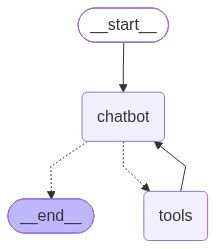

In [17]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# 1. State Schema 설정
class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

# 2. chatbot node용 함수
def chatbot(state:State) -> dict:
    response = llm_with_tools.invoke(state['messages'])

    return {'messages': [response]}

# 3. graph 만들기 함수
def build_graph():
    # 그래프 Builder 생성
    workflow = StateGraph(State)

    # 노드 등록
    workflow.add_node('chatbot', chatbot)
    workflow.add_node('tools', ToolNode(tools))

    # 엣지 등록
    workflow.add_edge(START, 'chatbot')
    workflow.add_edge('tools', 'chatbot')

    # 분기 조건
    workflow.add_conditional_edges(
        'chatbot', # 분기할 node
        tools_condition # chatbot의 AIMessage에 tool_calls가 있으면 'tools'없으면 END
    )

    # checkPoint에 중단 위치와 State를 저장
    return workflow.compile(
        checkpointer=InMemorySaver(),
    )

graph = build_graph()
display(graph)


## 실행 준비: thread_id로 checkpoint를 찾는 함수 만들기

`graph.get_state(config)`는 `configurable.thread_id`에 대응하는 최신 checkpoint를 `StateSnapshot`으로 반환한다.<br>
 이 `thread_id`는 사용자 이름이 아니라 **한 실행 이력을 구분하는 key**이며, 최초 실행·상태 조회·재개에 같은 값을 사용해야 한다.

- `snapshot.values`: 그 시점의 State 값이며 여기서는 `messages`를 포함한다.
- `snapshot.next`: 다음에 실행할 Node 이름의 tuple이다. `()`이면 대기 Node 없이 완료된 상태이다.
- `snapshot.tasks`: pending task의 상세 기록이다. Node 이름·오류·interrupt 정보를 확인할 때 사용한다.

아래 셀은 `config`와 조회 함수를 만든 뒤 아직 실행하지 않은 thread를 한 번 조회한다. 입력은 `graph`와 `config`, 출력은 저장된 messages와 다음 Node이며, 같은 함수는 중단 전후 상태 비교에 계속 사용된다.


In [18]:
from pprint import pprint

# 1. 최초 실행 / snapshot 조회 / interrupt 재개 시 함께 전달할 설정
config = {
    'configurable':{
        'thread_id': 'cake-customer-1'
    }
}

# 2. 입력 graph·config → StateSnapshot 조회 → messages·next 출력 함수
def print_snapshot(graph, config):
    snapshot = graph.get_state(
        config,  #
    )
    print("Messages:")
    pprint(
        snapshot.values.get(
            "messages",
            [],
        )
    )
    print("Next:", snapshot.next)

# 3. print_snapshot(graph, config): 새 thread의 초기 저장 상태 확인
print_snapshot(
    graph,
    config,
)


Messages:
[]
Next: ()


## 실행 경로 A: interrupt 없이 END까지 진행하기

먼저 사람 확인이 필요 없는 질문을 실행한다. 모델이 `tool_calls`를 만들지 않으면 `tools_condition`이 곧바로 `END`를 선택하므로 `interrupt()`는 호출되지 않는다.

입력 질문은 `chatbot`에서 최종 `AIMessage`로 바뀌고, 반환된 State의 마지막 message를 출력한다. 이 결과를 뒤의 중단 경로와 비교하면 HITL이 **모든 질문을 멈추는 기능이 아니라 필요한 분기만 멈추는 기능**임을 확인할 수 있다.


In [19]:
user_input = 'Agent 개발에서 LangGraph의 특징을 간단히 설명해줘'

response = graph.invoke({
    'messages':[('human', user_input)] # humanMessage로 자동변환
    },
    config=config # thread_id 설정
)

print(response['messages'][-1].content)

[{'type': 'text', 'text': 'LangGraph는 **LLM 기반 Agent의 상태(state)와 실행 흐름을 그래프 형태로 관리하는 프레임워크**입니다.\n\n주요 특징은 다음과 같습니다.\n\n- **그래프 기반 워크플로우**: Agent의 작업을 노드(node), 노드 간 이동을 엣지(edge)로 표현합니다.\n- **상태 관리**: 대화 기록, 중간 결과, 도구 호출 결과 등을 하나의 상태로 관리합니다.\n- **조건부 실행**: 상황에 따라 다음 단계나 사용할 도구를 동적으로 선택할 수 있습니다.\n- **반복·순환 흐름 지원**: 단순한 일회성 체인뿐 아니라, 결과를 검토하고 다시 실행하는 루프를 구성할 수 있습니다.\n- **Human-in-the-loop**: 중요한 작업에서 사람의 승인이나 개입을 쉽게 삽입할 수 있습니다.\n- **체크포인트와 복구**: 실행 상태를 저장해 중단된 작업을 이어가거나 디버깅할 수 있습니다.\n- **멀티 에이전트 구성**: 여러 Agent가 역할을 나누어 협력하는 구조를 만들 수 있습니다.\n\n즉, LangGraph는 단순한 프롬프트 체인보다 **복잡하고 상태를 유지하며 반복적으로 의사결정하는 Agent 시스템**을 구축하는 데 적합합니다.', 'annotations': [], 'id': 'msg_0aafc7447276e184006a84079bbaf8819a87ee83ee821ea7ff', 'phase': 'final_answer'}]


### 실행 결과 A: 완료된 checkpoint 확인하기

같은 `thread_id`의 최신 snapshot을 다시 읽는다. messages가 남아 있어도 `next=()`이면 대기 중인 Node가 없으므로 실행은 완료된 상태이다.


In [20]:
print_snapshot(
    graph, config
)

Messages:
[HumanMessage(content='Agent 개발에서 LangGraph의 특징을 간단히 설명해줘', additional_kwargs={}, response_metadata={}, id='5f63de3a-ac41-4ca9-9c87-49b2136699e2'),
 AIMessage(content=[{'type': 'text', 'text': 'LangGraph는 **LLM 기반 Agent의 상태(state)와 실행 흐름을 그래프 형태로 관리하는 프레임워크**입니다.\n\n주요 특징은 다음과 같습니다.\n\n- **그래프 기반 워크플로우**: Agent의 작업을 노드(node), 노드 간 이동을 엣지(edge)로 표현합니다.\n- **상태 관리**: 대화 기록, 중간 결과, 도구 호출 결과 등을 하나의 상태로 관리합니다.\n- **조건부 실행**: 상황에 따라 다음 단계나 사용할 도구를 동적으로 선택할 수 있습니다.\n- **반복·순환 흐름 지원**: 단순한 일회성 체인뿐 아니라, 결과를 검토하고 다시 실행하는 루프를 구성할 수 있습니다.\n- **Human-in-the-loop**: 중요한 작업에서 사람의 승인이나 개입을 쉽게 삽입할 수 있습니다.\n- **체크포인트와 복구**: 실행 상태를 저장해 중단된 작업을 이어가거나 디버깅할 수 있습니다.\n- **멀티 에이전트 구성**: 여러 Agent가 역할을 나누어 협력하는 구조를 만들 수 있습니다.\n\n즉, LangGraph는 단순한 프롬프트 체인보다 **복잡하고 상태를 유지하며 반복적으로 의사결정하는 Agent 시스템**을 구축하는 데 적합합니다.', 'annotations': [], 'id': 'msg_0aafc7447276e184006a84079bbaf8819a87ee83ee821ea7ff', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_0aafc7447276e184006a84079b0eb

## 실행 경로 B: 사람 확인용 thread 준비하기

재고와 가격은 모델이 임의로 확정하면 안 된다. Prompt에 “추측하지 말고 `human_assist`를 사용한다”는 정책을 넣어 사람 확인 경로를 유도한다.

앞의 일반 질문과 checkpoint가 섞이지 않도록 **새 graph와 새 `thread_id`**를 사용한다. 입력 문의는 매장 정책과 결합된 Prompt가 되고, 다음 셀의 첫 `invoke()`에서 `chatbot`에 전달된다.


In [21]:
graph = build_graph()

config = {
    'configurable':{
        'thread_id': 'cake-order-approval-1'
    }
}

def get_human_prompt(user_input: str) -> str:
    return f"""
당신은 프리미엄 케이크 매장의 안내 Agent이다.
- 운영 시간: 매일 09:00~21:00
- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.

사용자 문의:
{user_input}

답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.
"""

prompt = get_human_prompt(
    '4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘'
)




### 1단계: interrupt payload를 받고 멈추기

이번 `invoke()`는 최종 답변을 받기 위한 호출이 아니라 **사람에게 보여 줄 중단 요청을 얻는 호출**이다.

입력 Prompt는 `chatbot → AIMessage.tool_calls → ToolNode → human_assist → interrupt` 순서로 전달된다. `interrupt()`에서 실행이 멈추면 호출자는 반환 dict의 `__interrupt__`에서 payload를 읽는다. 이 payload는 사람의 답변이 아니라 **사람에게 전달할 질문**이다.


In [22]:
response = graph.invoke({
    'messages':[('human', prompt)]
    },
    config=config, # 'cake-order-approval-1' check point
)

# interrupt 확인
# interrupt 상태면 dict의 value 반환
# - __interrupt__ : key
print(response.get('__interrupt__', []))



[Interrupt(value={'query': '홈페이지에서 구매할 수 없는 4호 케이크가 현재 구매 가능한지 직원에게 확인해 주세요.'}, id='5a4f3fbfc73fc4a94d0c9be4c32fdc0a')]


### 2단계: 중단 checkpoint와 대기 Node 확인하기

중단 직후 Checkpointer는 messages뿐 아니라 아직 끝나지 않은 실행도 checkpoint에 보존한다.

- `snapshot.tasks`: 중단된 Tool 실행을 포함한 pending task의 상세 정보이다.
- `snapshot.next`: 다음에 이어서 실행할 Node 이름만 담은 간단한 tuple이다.

아래 helper는 `tasks`를 직접 출력하지 않고 `next`만 보여 준다. 따라서 `next`가 비어 있지 않으면 **실행이 END가 아니라 특정 Node에서 대기 중**이라고 해석한다.


In [23]:
print_snapshot(graph, config)

Messages:
[HumanMessage(content='\n당신은 프리미엄 케이크 매장의 안내 Agent이다.\n- 운영 시간: 매일 09:00~21:00\n- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크\n- 매장 위치: 서울 강남구 신사동 123-45\n- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.\n\n사용자 문의:\n4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘\n\n답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.\n', additional_kwargs={}, response_metadata={}, id='aba9ffab-b830-4617-bfa1-652f84adf965'),
 AIMessage(content=[{'id': 'rs_01130b92baea602e006a840a785288819aba8a62d1e978a54b', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqhAp5zCqol7y_snE8uqWWeLVaU-K8sq0wbOhvnn-DQ5gDEr8-GgtYpqsRK8zSYsaIZ7NfeYGVw8mkcd6w_e1r4aTTzl1fTTvQb0D8yb7LMP9bjttSrtTj2glP1B89mh7mhRv99Ux2Wcjy_-lNtaXstSKkuWiweUc93ulXpggvco0YvWorFdUhb0iQxLnld7l_g1KoaLpvKwsHmvd3_ek-nkLIZltWLYqpHkphi-_d16BFId_llm2HB-SqMNIx0Po-iqhOd-76UmS8hd-fvG5N4FgLoZeuGuiaDM-coegwWrVIveNWYGuPKsFlln5Q7bJ_gJaqAf838KGatYw4kLS5O32UK149P2vAsQAeu2YsYuR2mzeL5TRDnWz3meEL2ygfZCxc7-mlI4KdPTjXjppenFauq5Llk7SKiXKRVwirsJk

### 3단계: 사람의 검토 결과로 interrupt 재개하기

아래 `human_response` 문자열은 실제 서비스에서 담당자가 UI로 입력한 **사람의 검토 결과**를 수업용으로 대신한 값이다. 이 값을 `Command(resume={"data": ...})`에 담아 **같은 `thread_id`**로 전달한다.

`resume`은 새 사용자 질문을 추가하지 않고 중단된 `interrupt()`의 반환값을 공급한다. `Command`의 `update`는 State 값을 갱신할 때 사용하는 선택지이지만, 현재 `human_assist`는 `interrupt()`의 반환값을 기다리므로 `resume`이 필요하다.

재개 시 `interrupt()`가 있는 Node는 처음부터 다시 실행될 수 있다. 따라서 interrupt 앞에서 파일 저장·결제 같은 side effect를 수행한다면 여러 번 실행되어도 결과가 안전한 멱등 작업으로 설계해야 한다.

값의 흐름은 `resume dict → interrupt() 반환값 → human_assist 반환 문자열 → ToolMessage → chatbot 재판단 → END`이다.


In [24]:
from langgraph.types import Command

# 1. 사람의 응답(str)
human_response = (
    '죄송합니다. 홈페이지의 일시적인 오류로 인해 주문이 되지 않았습니다.'
    '현재 복구되어 4호 케이크 주문이 가능합니다.'
    '가격은 5만원입니다'
)

# 2. Command(resume=...)형태로 변경
resume_command = Command(
    resume={
        'data':human_response,
    }
)

# 3. graph에 invoke
response = graph.invoke(
    resume_command,
    config=config,
)

print(response['messages'][-1].content)



[{'type': 'text', 'text': '홈페이지의 일시적인 오류로 주문이 되지 않았으나 현재 복구되어 4호 케이크 주문이 가능합니다. 가격은 5만 원입니다.', 'annotations': [], 'id': 'msg_01130b92baea602e006a840c5f5718819a81ad157c25865ea7', 'phase': 'final_answer'}]


### 4단계: END와 저장된 message 확인하기

마지막으로 같은 thread의 최신 checkpoint를 확인한다. messages에는 이전의 `AIMessage.tool_calls`, 사람 답변을 담은 `ToolMessage`, 이를 반영한 최종 `AIMessage`가 함께 남는다.

`next=()`이면 저장된 대화 State는 존재하지만 pending task는 없으며, 그래프가 `END`까지 완료되었다고 해석한다.


In [25]:
print_snapshot(graph, config)

Messages:
[HumanMessage(content='\n당신은 프리미엄 케이크 매장의 안내 Agent이다.\n- 운영 시간: 매일 09:00~21:00\n- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크\n- 매장 위치: 서울 강남구 신사동 123-45\n- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.\n\n사용자 문의:\n4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘\n\n답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.\n', additional_kwargs={}, response_metadata={}, id='aba9ffab-b830-4617-bfa1-652f84adf965'),
 AIMessage(content=[{'id': 'rs_01130b92baea602e006a840a785288819aba8a62d1e978a54b', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqhAp5zCqol7y_snE8uqWWeLVaU-K8sq0wbOhvnn-DQ5gDEr8-GgtYpqsRK8zSYsaIZ7NfeYGVw8mkcd6w_e1r4aTTzl1fTTvQb0D8yb7LMP9bjttSrtTj2glP1B89mh7mhRv99Ux2Wcjy_-lNtaXstSKkuWiweUc93ulXpggvco0YvWorFdUhb0iQxLnld7l_g1KoaLpvKwsHmvd3_ek-nkLIZltWLYqpHkphi-_d16BFId_llm2HB-SqMNIx0Po-iqhOd-76UmS8hd-fvG5N4FgLoZeuGuiaDM-coegwWrVIveNWYGuPKsFlln5Q7bJ_gJaqAf838KGatYw4kLS5O32UK149P2vAsQAeu2YsYuR2mzeL5TRDnWz3meEL2ygfZCxc7-mlI4KdPTjXjppenFauq5Llk7SKiXKRVwirsJk